In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Underestanding Data

In [324]:
file_path = "items.csv"
item_df = pd.read_csv(file_path)
file_path2 = "reviews.csv"
review_df = pd.read_csv(file_path2)
item_df.head()

,asin,brand,title,url,image,rating,reviewUrl,totalReviews,price,originalPrice
0,B0000SX2UC,NaN,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,https://www.amazon.com/Dual-Band-Tri-Mode-Acti...,https://m.media-amazon.com/images/I/2143EBQ210...,3.0,https://www.amazon.com/product-reviews/B0000SX2UC,14,0.00,0.0
1,B0009N5L7K,Motorola,Motorola I265 phone,https://www.amazon.com/Motorola-i265-I265-phon...,https://m.media-amazon.com/images/I/419WBAVDAR...,3.0,https://www.amazon.com/product-reviews/B0009N5L7K,7,49.95,0.0
2,B000SKTZ0S,Motorola,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...,https://www.amazon.com/MOTOROLA-C168i-CINGULAR...,https://m.media-amazon.com/images/I/71b+q3ydkI...,2.7,https://www.amazon.com/product-reviews/B000SKTZ0S,22,99.99,0.0
3,B001AO4OUC,Motorola,Motorola i335 Cell Phone Boost Mobile,https://www.amazon.com/Motorola-i335-Phone-Boo...,https://m.media-amazon.com/images/I/710UO8gdT+...,3.3,https://www.amazon.com/product-reviews/B001AO4OUC,21,0.00,0.0
4,B001DCJAJG,Motorola,Motorola V365 no contract cellular phone AT&T,https://www.amazon.com/Motorola-V365-contract-...,https://m.media-amazon.com/images/I/61LYNCVrrK...,3.1,https://www.amazon.com/product-reviews/B001DCJAJG,12,149.99,0.0


## Preprocessing

In [327]:
item_df.isnull().sum()

asin             0
brand            4
title            0
url              0
image            0
rating           0
reviewUrl        0
totalReviews     0
price            0
originalPrice    0
dtype: int64

In [329]:
item_df = item_df.dropna(subset=['brand'])

In [331]:
item_df = item_df[item_df['price'] > 0]

In [333]:
if item_df['originalPrice'].nunique() <= 1:
    item_df= item_df.drop(columns=['originalPrice'])

In [335]:
item_df = item_df.drop(columns=['url', 'image', 'reviewUrl'])

In [337]:
item_df.head()

,asin,brand,title,rating,totalReviews,price,originalPrice
1,B0009N5L7K,Motorola,Motorola I265 phone,3.0,7,49.95,0.0
2,B000SKTZ0S,Motorola,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...,2.7,22,99.99,0.0
4,B001DCJAJG,Motorola,Motorola V365 no contract cellular phone AT&T,3.1,12,149.99,0.0
9,B002WTC1NG,Motorola,Motorola Barrage V860 Phone (Verizon Wireless),3.6,352,139.99,0.0
10,B0033SFV5A,Samsung,Verizon or PagePlus Samsung Smooth U350 Great ...,3.3,57,64.99,0.0


In [339]:
print(item_df.duplicated(subset='asin').sum())

0


In [341]:
item_df = item_df.reset_index(drop=True)

In [343]:
item_df.head()

,asin,brand,title,rating,totalReviews,price,originalPrice
0,B0009N5L7K,Motorola,Motorola I265 phone,3.0,7,49.95,0.0
1,B000SKTZ0S,Motorola,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...,2.7,22,99.99,0.0
2,B001DCJAJG,Motorola,Motorola V365 no contract cellular phone AT&T,3.1,12,149.99,0.0
3,B002WTC1NG,Motorola,Motorola Barrage V860 Phone (Verizon Wireless),3.6,352,139.99,0.0
4,B0033SFV5A,Samsung,Verizon or PagePlus Samsung Smooth U350 Great ...,3.3,57,64.99,0.0


In [345]:
print(item_df.dtypes)

asin              object
brand             object
title             object
rating           float64
totalReviews       int64
price            float64
originalPrice    float64
dtype: object


In [349]:
review_df.head()

,asin,name,rating,date,verified,title,body,helpfulVotes
0,B0000SX2UC,Janet,3,"October 11, 2005",False,"Def not best, but not worst",I had the Samsung A600 for awhile which is abs...,1.0
1,B0000SX2UC,Luke Wyatt,1,"January 7, 2004",False,Text Messaging Doesn't Work,Due to a software issue between Nokia and Spri...,17.0
2,B0000SX2UC,Brooke,5,"December 30, 2003",False,Love This Phone,"This is a great, reliable phone. I also purcha...",5.0
3,B0000SX2UC,amy m. teague,3,"March 18, 2004",False,"Love the Phone, BUT...!","I love the phone and all, because I really did...",1.0
4,B0000SX2UC,tristazbimmer,4,"August 28, 2005",False,"Great phone service and options, lousy case!",The phone has been great for every purpose it ...,1.0


In [351]:
review_df = review_df.drop(columns=['date', 'verified', 'title', 'body', 'helpfulVotes'])

In [353]:
review_df.head()

,asin,name,rating
0,B0000SX2UC,Janet,3
1,B0000SX2UC,Luke Wyatt,1
2,B0000SX2UC,Brooke,5
3,B0000SX2UC,amy m. teague,3
4,B0000SX2UC,tristazbimmer,4


In [355]:
review_df.isnull().sum()

asin      0
name      3
rating    0
dtype: int64

In [359]:
review_df = review_df.dropna(subset=['name'])

In [361]:
print(review_df.dtypes)

asin      object
name      object
rating     int64
dtype: object


In [363]:
review_df = review_df.reset_index(drop=True)

In [365]:
review_df.head()

,asin,name,rating
0,B0000SX2UC,Janet,3
1,B0000SX2UC,Luke Wyatt,1
2,B0000SX2UC,Brooke,5
3,B0000SX2UC,amy m. teague,3
4,B0000SX2UC,tristazbimmer,4


In [369]:
review_df.columns = ['item_Id', 'user_Id', 'rating']

In [371]:
review_df.head()

,item_Id,user_Id,rating
0,B0000SX2UC,Janet,3
1,B0000SX2UC,Luke Wyatt,1
2,B0000SX2UC,Brooke,5
3,B0000SX2UC,amy m. teague,3
4,B0000SX2UC,tristazbimmer,4


## EDA

In [374]:
print("brand: ", item_df['brand'].nunique())
print(item_df['brand'].value_counts())

brand:  10
brand
Samsung     269
Motorola     84
Apple        61
Xiaomi       45
Nokia        35
Google       31
HUAWEI       30
Sony         24
OnePlus       9
ASUS          5
Name: count, dtype: int64


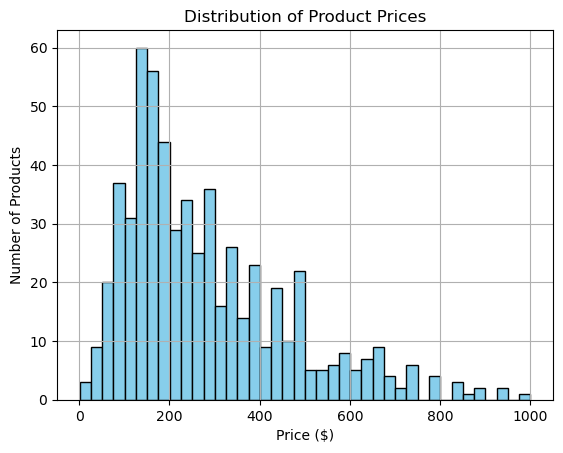

In [376]:
item_df['price'].hist(bins=40, color='skyblue', edgecolor='black')
plt.title("Distribution of Product Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Products")
plt.show()

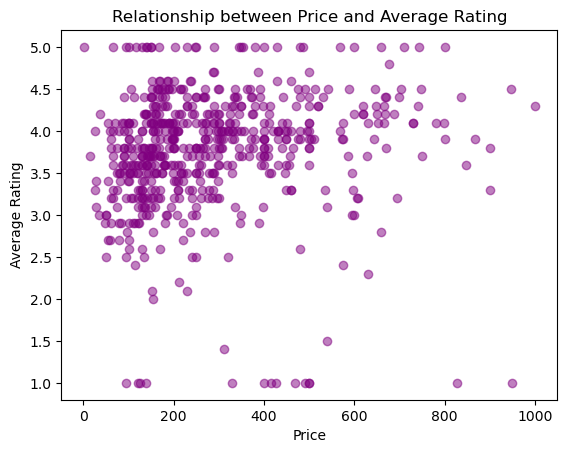

In [378]:
plt.scatter(item_df['price'], item_df['rating'], alpha=0.5, color='purple')
plt.title('Relationship between Price and Average Rating')
plt.xlabel('Price')
plt.ylabel('Average Rating')
plt.show()

In [380]:
top_rated = item_df.sort_values(by='rating', ascending=False).head()
print('top_rated :', top_rated[['title', 'brand', 'rating']])

top_rated :                                                  title     brand  rating
592  Straight Talk Samsung Galaxy A10e Smartphone 5...   Samsung     5.0
303  Samsung Galaxy A30 Single SIM 32GB (SM-A305G) ...   Samsung     5.0
365  Samsung Galaxy S9 - GSM Unlocked - 64GB (Renew...   Samsung     5.0
470  Huawei Y7 2019 DUB-LX3 32GB Unlocked GSM Phone...    HUAWEI     5.0
493  Verizon Prepaid 4G Smartphone - Motorola Moto ...  Motorola     5.0


In [382]:
low_reted = item_df.sort_values(by='rating', ascending=True).head()
print('low_rated :', low_reted[['title', 'brand', 'rating']])

low_rated :                                                  title     brand  rating
483  Motorola G7 Play 32GB GSM Nano-SIM Phone w/ 13...  Motorola     1.0
571  Samsung Galaxy S10e G970U Sprint + GSM Unlocke...   Samsung     1.0
133  Samsung Galaxy S6 Edge G925P 32GB Gold - Sprin...   Samsung     1.0
522  Samsung Galaxy A70 128GB/6GB SM-A705MN/DS 6.7"...   Samsung     1.0
297  OnePlus Factory Unlocked Phone - 6.28" Screen ...   OnePlus     1.0


In [386]:
print('Name :', review_df['user_Id'].nunique())
print('Asin :', review_df['item_Id'].nunique())

Name : 47322
Asin : 720


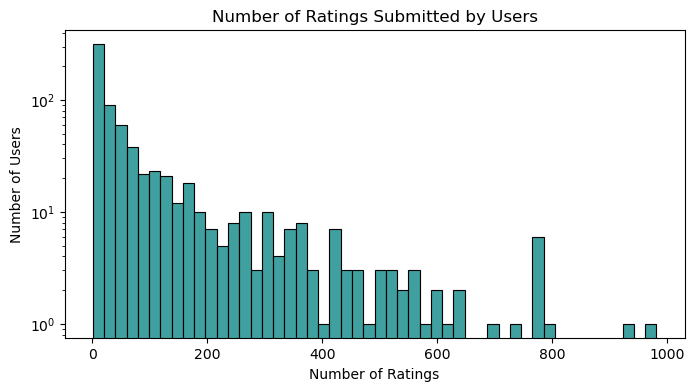

In [388]:
import seaborn as sns
reviews_per_user = review_df.groupby('item_Id').size()

plt.figure(figsize=(8,4))
sns.histplot(reviews_per_user, bins=50, color='teal', edgecolor='black', kde=False)
plt.title("Number of Ratings Submitted by Users")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.yscale('log')
plt.show()

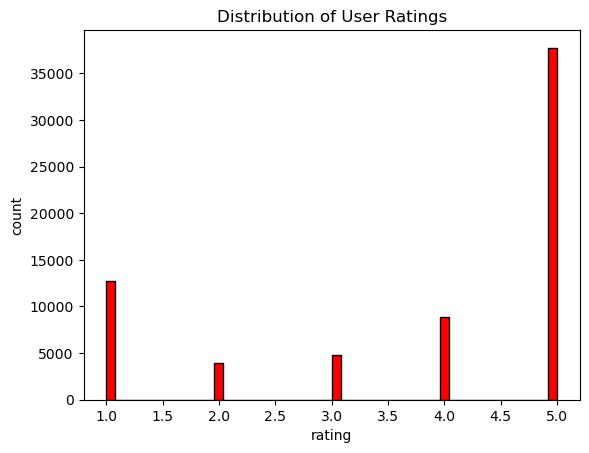

In [390]:
review_df['rating'].hist(bins=50, grid=False, color='red', edgecolor='black')
plt.title('Distribution of User Ratings')
plt.xlabel('rating')
plt.ylabel('count')
plt.show()

In [392]:
n_users = review_df['user_Id'].nunique()
n_items = review_df['item_Id'].nunique()
n_interactions = len(review_df)
sparsity = 1 - (n_interactions / (n_users * n_items))
print(f"User-item matrix sparsity: {sparsity:.2%}")

User-item matrix sparsity: 99.80%


## Content_Base System 

In [395]:
item_df['combined_features'] = item_df['title'].fillna('')+ '' + item_df['brand'].fillna('')

In [397]:
item_df[['title', 'brand', 'combined_features']].head(10)

,title,brand,combined_features
0,Motorola I265 phone,Motorola,Motorola I265 phoneMotorola
1,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...,Motorola,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...
2,Motorola V365 no contract cellular phone AT&T,Motorola,Motorola V365 no contract cellular phone AT&TM...
3,Motorola Barrage V860 Phone (Verizon Wireless),Motorola,Motorola Barrage V860 Phone (Verizon Wireless)...
4,Verizon or PagePlus Samsung Smooth U350 Great ...,Samsung,Verizon or PagePlus Samsung Smooth U350 Great ...
5,Samsung Smooth Verizon Wireless Prepaid Mobile...,Samsung,Samsung Smooth Verizon Wireless Prepaid Mobile...
6,"Samsung Rugby II, Black (AT&T)",Samsung,"Samsung Rugby II, Black (AT&T)Samsung"
7,Motorola i570 Nextel iDen PTT rugged black cel...,Motorola,Motorola i570 Nextel iDen PTT rugged black cel...
8,"Samsung Gusto, Black (Verizon Wireless)",Samsung,"Samsung Gusto, Black (Verizon Wireless)Samsung"
9,Samsung T201G Prepaid Phone (Net10),Samsung,Samsung T201G Prepaid Phone (Net10)Samsung


In [399]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(item_df['combined_features'])

In [401]:
print(tfidf_matrix.shape)

(593, 966)


In [403]:
print(tfidf_matrix)

  (0, 691)	0.6183777725761561
  (0, 481)	0.7164512590729658
  (0, 615)	0.32296520517931
  (1, 262)	0.29168345546406715
  (1, 447)	0.43579460853891083
  (1, 709)	0.30093755690289103
  (1, 275)	0.4638944820337342
  (1, 245)	0.4638944820337342
  (1, 691)	0.40039295468831776
  (1, 615)	0.20911649560841422
  (2, 839)	0.48832719946079656
  (2, 690)	0.20186032962480469
  (2, 265)	0.46598670722506214
  (2, 283)	0.4225286910239962
  (2, 868)	0.5198143547859514
  (2, 615)	0.23432431393284464
  (3, 902)	0.32822417031098705
  (3, 871)	0.23040044436368623
  (3, 869)	0.5321289091476091
  (3, 216)	0.5321289091476091
  (3, 690)	0.20664245997526495
  (3, 615)	0.4797510511659169
  (4, 692)	0.35512065838231466
  (4, 259)	0.21324188273727818
  (4, 229)	0.1929467630826977
  :	:
  (590, 249)	0.43299283185499426
  (590, 645)	0.43299283185499426
  (590, 892)	0.43299283185499426
  (590, 912)	0.2722533901092022
  (590, 807)	0.2696127659188748
  (590, 797)	0.1545787431896464
  (590, 858)	0.08962058228164081
  (5

In [405]:
feature_name = vectorizer.get_feature_names_out()
print(feature_name[691])

phonemotorola


## Cosine Similarity

In [408]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [410]:
similarities = list(enumerate(cosine_sim[0]))
similarities_sorted = sorted(similarities, key=lambda x: x[1], reverse=True)
top_similar = similarities_sorted[1:7]
for index, score in top_similar:
    print(f"{item_df.iloc[index]['asin']} - Similarity Score: {score:.2f}")

B0714DBSNH - Similarity Score: 0.34
B000SKTZ0S - Similarity Score: 0.32
B003W646YK - Similarity Score: 0.28
B07RJ16QXJ - Similarity Score: 0.22
B00XQVDW6Y - Similarity Score: 0.17
B01ATTBXY8 - Similarity Score: 0.17


## User_Profile

In [413]:
def recommend_similar(asin, n=5):
    index = item_df[item_df['asin'] == asin].index[0]
    sim_scores = list(enumerate(cosine_sim[index]))
    sim_scores = sorted(sim_scores, key=lambda x:x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    similar_indexes = [i[0] for i in sim_scores]
    return item_df[['asin', 'title', 'brand', 'rating']].iloc[similar_indexes]

In [415]:
item_df.head(10)

,asin,brand,title,rating,totalReviews,price,originalPrice,combined_features
0,B0009N5L7K,Motorola,Motorola I265 phone,3.0,7,49.95,0.0,Motorola I265 phoneMotorola
1,B000SKTZ0S,Motorola,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...,2.7,22,99.99,0.0,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...
2,B001DCJAJG,Motorola,Motorola V365 no contract cellular phone AT&T,3.1,12,149.99,0.0,Motorola V365 no contract cellular phone AT&TM...
3,B002WTC1NG,Motorola,Motorola Barrage V860 Phone (Verizon Wireless),3.6,352,139.99,0.0,Motorola Barrage V860 Phone (Verizon Wireless)...
4,B0033SFV5A,Samsung,Verizon or PagePlus Samsung Smooth U350 Great ...,3.3,57,64.99,0.0,Verizon or PagePlus Samsung Smooth U350 Great ...
5,B003FCO9XE,Samsung,Samsung Smooth Verizon Wireless Prepaid Mobile...,2.6,78,99.99,0.0,Samsung Smooth Verizon Wireless Prepaid Mobile...
6,B003P2VNAQ,Samsung,"Samsung Rugby II, Black (AT&T)",3.6,70,179.00,0.0,"Samsung Rugby II, Black (AT&T)Samsung"
7,B003W646YK,Motorola,Motorola i570 Nextel iDen PTT rugged black cel...,2.9,3,79.00,0.0,Motorola i570 Nextel iDen PTT rugged black cel...
8,B003XREZ4O,Samsung,"Samsung Gusto, Black (Verizon Wireless)",3.4,16,99.99,0.0,"Samsung Gusto, Black (Verizon Wireless)Samsung"
9,B0046REOWS,Samsung,Samsung T201G Prepaid Phone (Net10),3.6,22,64.94,0.0,Samsung T201G Prepaid Phone (Net10)Samsung


In [417]:
recommend_similar('B0009N5L7K')

,asin,title,brand,rating
162,B0714DBSNH,Verizon Motorola Moto E4 Plus Carrier Locked P...,Motorola,3.8
1,B000SKTZ0S,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...,Motorola,2.7
7,B003W646YK,Motorola i570 Nextel iDen PTT rugged black cel...,Motorola,2.9
479,B07RJ16QXJ,Motorola One - 64GB - Black/White - Unlocked (...,Motorola,2.9
57,B00XQVDW6Y,Motorola Moto E LTE - No Contract Phone (U.S. ...,Motorola,3.7


## Collaborative Filtering

In [420]:
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

review_df['item_Id'] = user_encoder.fit_transform(reviw_df['item_Id'])
review_df['user_Id'] = item_encoder.fit_transform(reviw_df['user_Id'])

In [422]:
user_item_matrix = review_df.pivot_table(
    index="user_Id",
    columns="item_Id",
    values="rating"
)

In [424]:
print(user_item_matrix.shape)

(47322, 720)


In [426]:
user_item_matrix.head()

item_Id,0,1,2,3,4,5,6,7,8,9,...,710,711,712,713,714,715,716,717,718,719
user_Id,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cosine Similarity

### IBCF

In [430]:
item_user_matrix = user_item_matrix.T
item_user_matrix_filled = item_user_matrix.fillna(0)
item_similarity = cosine_similarity(item_user_matrix_filled)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=item_user_matrix_filled.index,
                                 columns=item_user_matrix_filled.index)

item_similarity_df.iloc[:5, :5]

item_Id,0,1,2,3,4
item_Id,,,,,
0,1.000000,0.0,0.011814,0.065262,0.0
1,0.000000,1.0,0.000000,0.000000,0.0
2,0.011814,0.0,1.000000,0.016105,0.0
3,0.065262,0.0,0.016105,1.000000,0.0
4,0.000000,0.0,0.000000,0.000000,1.0


In [431]:
item_similarity_df.columns.tolist()[:10]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [434]:
def recommend_similar_item(asin, item_similarity_df, top_n=5):
    if asin not in item_similarity_df.columns:
        return "Not Found"

    similar_scores = item_similarity_df[asin].sort_values(ascending=False)

    similar_scores = similar_scores.drop(labels=[asin])

    return similar_scores.head(top_n)

In [436]:
sample_asin = item_similarity_df.columns[6] 
recommend_similar_item(sample_asin, item_similarity_df)

item_Id
298    0.092501
144    0.025013
185    0.022684
99     0.020896
496    0.019293
Name: 6, dtype: float64

## Recommendation Generation

In [439]:
def generate_item_based_recommendations(user_name, user_item_matrix, item_similarity_df, top_n=5):
    if user_name not in user_item_matrix.index:
        return "User not found"

    user_ratings = user_item_matrix.loc[user_name]  
    rated_items = user_ratings.dropna().index       

    scores = {}

    for item in rated_items:
        similarity_scores = item_similarity_df[item]  
        user_rating = user_ratings[item]

        for other_item, similarity in similarity_scores.items():
            if pd.isna(user_ratings.get(other_item)):  
                if other_item not in scores:
                    scores[other_item] = 0
                scores[other_item] += similarity * user_rating

   
    sorted_scores = pd.Series(scores).sort_values(ascending=False)

    return sorted_scores.head(top_n)

In [441]:
user_item_matrix.index[:5]

Index([0, 1, 2, 3, 4], dtype='int64', name='user_Id')

In [443]:
user_name = user_item_matrix.index[200]

In [445]:
generate_item_based_recommendations(user_name, user_item_matrix, item_similarity_df)

42     0.329437
127    0.142821
531    0.142160
634    0.140732
19     0.127713
dtype: float64

## Weighted Hybrid

In [448]:
def get_content_base(asin, top_n=50):
    index = item_df[item_df['asin'] == asin].index[0]
    content_scores = list(enumerate(cosine_sim[index]))
    content_scores = sorted(content_scores, key=lambda x: x[1], reverse=True)
    content_scores = content_scores[1:top_n+1]

    content_dict = {i: score for i, score in content_scores}
    return content_dict

In [450]:
def get_collab_scores(user_name, top_n=50):
    collab_scores = generate_item_based_recommendations(user_name, user_item_matrix, item_similarity_df, top_n=top_n)

    collab_dict = collab_scores.to_dict()
    return collab_dict

In [452]:
from sklearn.preprocessing import MinMaxScaler

def hybrid_recommendation(user_name, asin, alpha=0.5, top_n=10):
    content_dict = get_content_base(asin, top_n=30)
    collab_dict = get_collab_scores(user_name, top_n=30)

    common_items = set(content_dict.keys()) & set(collab_dict.keys())
    if not common_items:
        return "NOT FOUND ITEM"

    content_scores = [[content_dict[i]] for i in common_items]
    collab_scores = [[collab_dict[i]] for i in common_items]
    
    scaler = MinMaxScaler()
    norm_content = scaler.fit_transform(content_scores)
    norm_collab = scaler.fit_transform(collab_scores)
    
    final_scores = {}
    for idx, item in enumerate(common_items):
        final_score = alpha * norm_content[idx][0] + (1 - alpha) * norm_collab[idx][0]
        final_scores[item] = final_score

    sorted_final = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    final_indexes = [i[0] for i in sorted_final]
    return item_df[['asin', 'title', 'brand', 'rating']].iloc[final_indexes]

In [454]:
hybrid_recommendation(user_name, 'B001DCJAJG', alpha=0.5, top_n=10)

,asin,title,brand,rating
450,B07QBJZ34C,"Motorola Moto G6 Play 16GB - 5.7"" 4G LTE Unloc...",Motorola,2.9
13,B007LU0HU0,Samsung Replenish SPH-M580 Blue No Contract Sp...,Samsung,2.5
